# Exploratory Data Analysis (EDA) — Diabetic Readmission Dataset

This notebook performs initial data exploration, checks missing values, 
understands variable distributions, and prepares the dataset for preprocessing.


## Set Working Directory
We set the working directory so Python can correctly locate the data folder.


In [4]:
import os
#Change the working directory to the ROOT of project
os.chdir("/Users/harimagar/Documents/PROJECTS/hospital-readmission-ml-and-nhs-ae-dashboard")



In [7]:
# Show the current working directory to confirm it changed correctly
os.getcwd()

'/Users/harimagar/Documents/PROJECTS/hospital-readmission-ml-and-nhs-ae-dashboard'

In [8]:
os.listdir("data")

['.DS_Store', 'ae_raw', 'ml_raw', 'placeholder.txt', 'processed']

## Import Required Libraries
We import pandas, numpy, seaborn, and matplotlib for data analysis and visualisation.


In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

Matplotlib is building the font cache; this may take a moment.


In [10]:
# Show all columns when printing the dataframe
pd.set_option('display.max_columns', None)

## Load the Diabetic Dataset
We load the raw dataset from the ml_raw folder.


In [11]:
#load dataset
df = pd.read_csv("data/ml_raw/diabetic_data.csv")
#check shape of dataset
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Basic EDA
We inspect structure, missing values, and target distribution.


In [12]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [13]:
#checking for missing values
df.isna().sum().sort_values(ascending=False)


max_glu_serum               96420
A1Cresult                   84748
encounter_id                    0
nateglinide                     0
glimepiride                     0
acetohexamide                   0
glipizide                       0
glyburide                       0
tolbutamide                     0
pioglitazone                    0
rosiglitazone                   0
acarbose                        0
miglitol                        0
troglitazone                    0
tolazamide                      0
examide                         0
citoglipton                     0
insulin                         0
glyburide-metformin             0
glipizide-metformin             0
glimepiride-pioglitazone        0
metformin-rosiglitazone         0
metformin-pioglitazone          0
change                          0
diabetesMed                     0
chlorpropamide                  0
repaglinide                     0
patient_nbr                     0
medical_specialty               0
race          

In [14]:
#checking the target variable distribution
df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

## Create Binary Target Variable
We convert readmission into a binary variable: 1 = <30 days, 0 = otherwise.


In [15]:
#create the binary target variable
df['readmitted_30'] = df['readmitted'].apply(lambda x: 1 if x == "<30" else 0)
df['readmitted_30'].value_counts()


readmitted_30
0    90409
1    11357
Name: count, dtype: int64

In [16]:
#summary of numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols].describe()


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted_30
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607,0.111599
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600,0.314874
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000,0.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000,0.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000,0.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000,1.000000


## Distribution of Time in Hospital
We visualise the distribution to understand patient stay patterns.


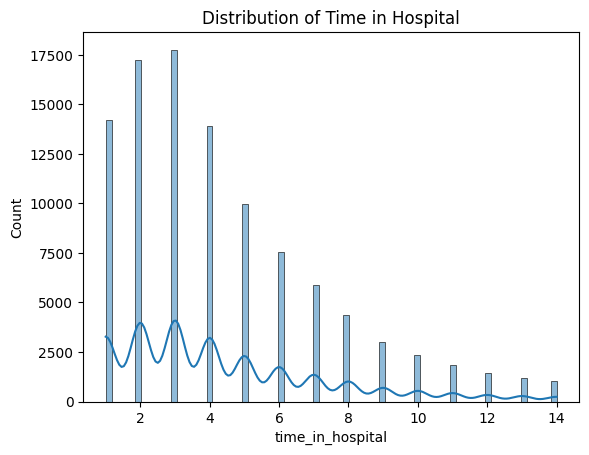

In [17]:
sns.histplot(df['time_in_hospital'], kde=True)
plt.title("Distribution of Time in Hospital")
plt.show()

## Mapping ID Columns
We convert admission_type_id, discharge_disposition_id, and admission_source_id 
into human-readable categories.


In [18]:
# Mapping for admission_type_id
admission_type_map = {
    1: "Emergency",
    2: "Urgent",
    3: "Elective",
    4: "Newborn",
    5: "Not Available",
    6: None,                # 6 means missing or unknown
    7: "Trauma Center",
    8: "Not Mapped"
}

# Create a new readable column
df['admission_type_desc'] = df['admission_type_id'].map(admission_type_map)


In [19]:
# Mapping for discharge_disposition_id
discharge_map = {
    1: "Discharged to home",
    2: "Transferred to short-term hospital",
    3: "Transferred to SNF",
    4: "Transferred to ICF",
    5: "Transferred to inpatient care",
    6: "Home with health service",
    7: "Left AMA",
    8: "Home IV provider",
    9: "Admitted as inpatient",
    10: "Neonate to another hospital",
    11: "Expired",
    12: "Still patient",
    13: "Hospice / home",
    14: "Hospice / medical facility",
    15: "Swing bed",
    16: "Referred to outpatient services",
    17: "Referred to this institution outpatient",
    18: None,
    19: "Expired at home (Medicaid hospice)",
    20: "Expired in medical facility (Medicaid hospice)",
    21: "Expired, place unknown",
    22: "Transferred to rehab facility",
    23: "Transferred to long-term care hospital",
    24: "Transferred to Medicaid nursing facility",
    25: "Not Mapped",
    26: "Unknown/Invalid",
    27: "Transferred to federal facility",
    28: "Transferred to psychiatric hospital",
    29: "Transferred to Critical Access Hospital",
    30: "Transferred to other healthcare institution"
}

df['discharge_desc'] = df['discharge_disposition_id'].map(discharge_map)


In [20]:
# Mapping for admission_source_id
admission_source_map = {
    1: "Physician Referral",
    2: "Clinic Referral",
    3: "HMO Referral",
    4: "Transfer from hospital",
    5: "Transfer from SNF",
    6: "Transfer from healthcare facility",
    7: "Emergency Room",
    8: "Court/Law Enforcement",
    9: "Not Available",
    10: "Transfer from critical access hospital",
    11: "Normal Delivery",
    12: "Premature Delivery",
    13: "Sick Baby",
    14: "Extramural Birth",
    15: "Not Available",
    17: None,
    18: "Transfer from Home Health Agency",
    19: "Readmission to Home Health Agency",
    20: "Not Mapped",
    21: "Unknown/Invalid",
    22: "Transfer from same facility",
    23: "Born inside hospital",
    24: "Born outside hospital",
    25: "Transfer from Ambulatory Surgery Center",
    26: "Transfer from Hospice"
}

df['admission_source_desc'] = df['admission_source_id'].map(admission_source_map)


In [21]:
df[['admission_type_id', 'admission_type_desc']].head()
df[['discharge_disposition_id', 'discharge_desc']].head()
df[['admission_source_id', 'admission_source_desc']].head()


,admission_source_id,admission_source_desc
0,1,Physician Referral
1,7,Emergency Room
2,7,Emergency Room
3,7,Emergency Room
4,7,Emergency Room
